In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [5]:
from google.colab import files
uploaded = files.upload()



Saving oasis_longitudinal.csv to oasis_longitudinal.csv


In [6]:
df = pd.read_csv("oasis_longitudinal.csv")
print("Rows, columns:" , df.shape)
df.head()

Rows, columns: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [8]:
first = df[df["Visit"] == 1].copy()
print("Rows before:", len(df))
print("Rows after keeping first visits:", len(first))
print("Unique people:", first["Subject ID"].nunique())

Rows before: 373
Rows after keeping first visits: 150
Unique people: 150


In [9]:
print(first["Group"].value_counts())
first["Demented"] = first["Group"].map({"Nondemented": 0, "Demented" : 1, "Converted" : 1})
first["Demented"].value_counts()

Group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64


,count
Demented,
1,78
0,72


In [10]:
print(first.isnull().sum())

for col in ["SES", "MMSE"]:
  first[col] = first[col].fillna(first[col].median())

print("Missing values left:", first.isnull().sum().sum())

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
M/F           0
Hand          0
Age           0
EDUC          0
SES           8
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
Demented      0
dtype: int64
Missing values left: 0


In [11]:
first["Male"] = (first["M/F"] == "M").astype(int)
clean = first[["Subject ID", "Male", "Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF", "Demented"]]
clean.head()

,Subject ID,Male,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Demented
0,OAS2_0001,1,87,14,2.0,27.0,0.0,1987,0.696,0.883,0
2,OAS2_0002,1,75,12,2.0,23.0,0.5,1678,0.736,1.046,1
5,OAS2_0004,0,88,18,3.0,28.0,0.0,1215,0.710,1.444,0
7,OAS2_0005,1,80,12,4.0,28.0,0.0,1689,0.712,1.039,0
10,OAS2_0007,1,71,16,2.0,28.0,0.5,1357,0.748,1.293,1


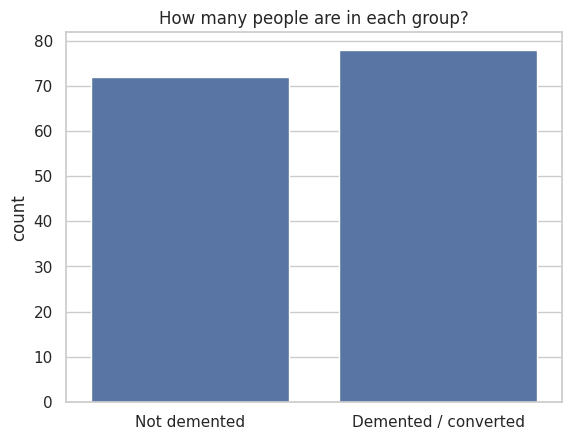

In [12]:
sns.countplot(data=clean, x="Demented")
plt.xticks([0, 1], ["Not demented", "Demented / converted"])
plt.xlabel("")
plt.title("How many people are in each group?")
plt.show()


In [13]:
def compare(col, label):
  sns.boxplot(data=clean, x="Demented", y=col)
  plt.xticks([0,1], ["Not demented", "Demented / converted"])
  plt.xlabel("")
  plt.ylabel(label)
  plt.title(f"{label} by group")
  plt.show()

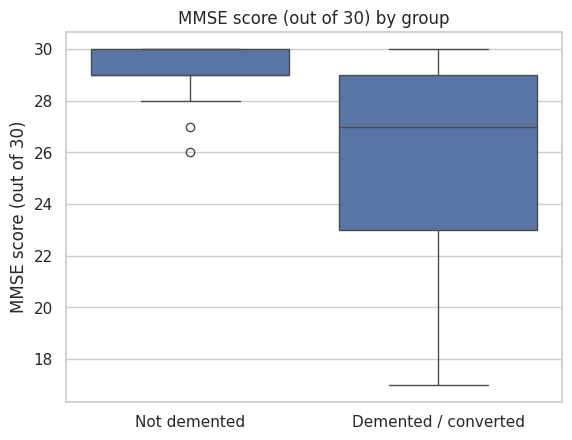

In [14]:
compare("MMSE", "MMSE score (out of 30)")


Mini-mental state examination. Range was tighter for non-demented, only a few anomalies outside the box. Demented group has an overall lower score, with a median of 27 compared to 29/30 for non-demented. There is some overlap as some people with dementia scored high, likely because some converted participiants were healthy at first visit and early dementia may not have shown up on short screening test. MMSE is useful predictor but not the only predictor needed.

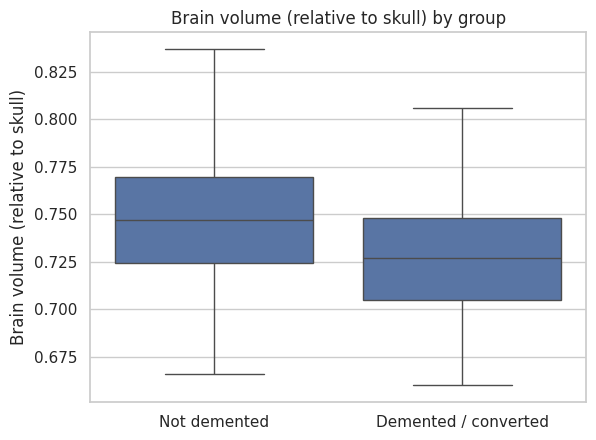

In [15]:
compare("nWBV", "Brain volume (relative to skull)")

A smaller brain volume can arise from atrophy, the loss of brain tissue due to synapses and neurons dying. In alzheimers, amyloid-beta clumps together outside neurons forming plaques and tau inside the neurones, disrupting internal transport. Combined with inflammation, this damage kills neurons leading to decreased brain size.
People with dementia tended to have a lower brain volume of 0.73, compared to non-demented of 0.75, consistent with brain atrophy. The groups overlap due to brain shrinking with age too, brain volume isn't enough alone to separate them.

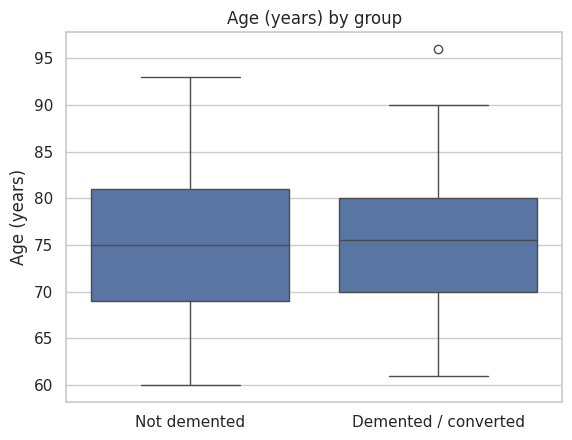

In [16]:
compare("Age", "Age (years)")


Almost both groups are identical in age, with a mediann of around 75. Age is the known biggest risk factor for dementia, so you would assume the dementia group to be older. Both groups were above 60, comparing older adults with older adults instead of younger people.
The similar ages strengthen the earlier findings: lower brain volume and MMSE scores are not explained by the group being older.

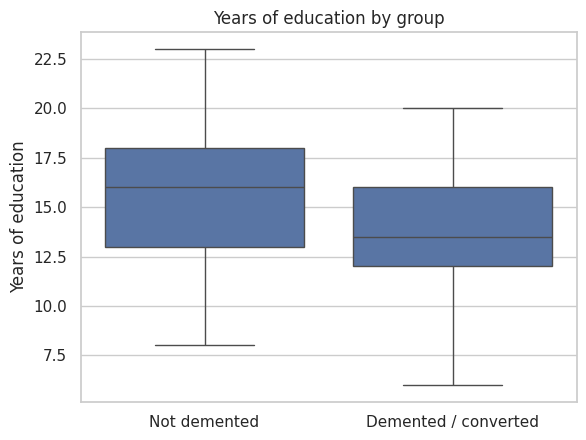

In [17]:
compare("EDUC", "Years of education")

The non-demented had a median of 16 years of education compared to 13.5 in dementia.
Cognitive reserve is the idea that education and mental activites help to build a stronger brain with efficient networks and alternative thinking routes, when disease damages this, a brain with more reserve can work around the damage for longer.

However this is a correlation: education can also be linked to socioeconmic status, healthcare access, lifestyle habits that can affect the brain. Highly educated individuals may also perform better on MMSE tests.

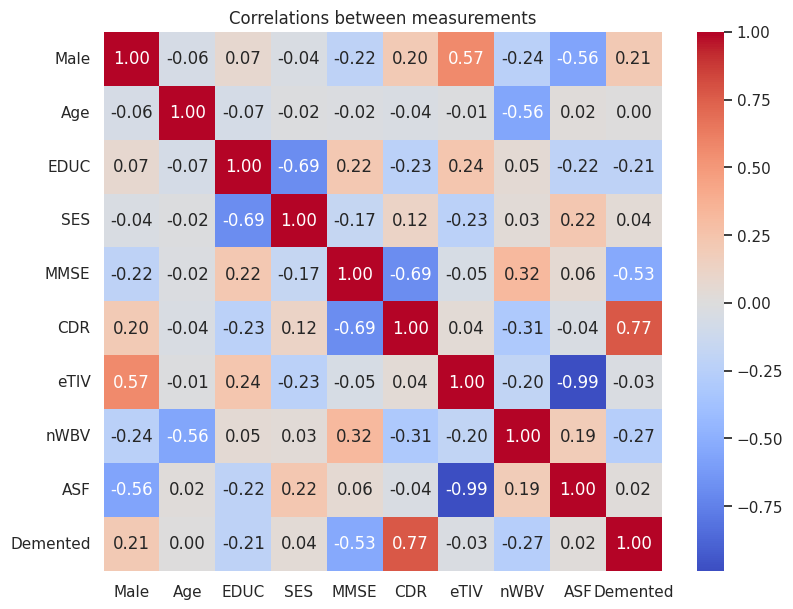

In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(clean.drop(columns=["Subject ID"]).corr(),
        annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations between measurements")
plt.show()



MMSE had the strongest link with dementia of -0.53, followed by brain volume -0.27, sex (0.21) more common in men and education -0.21 whilst age showed no link (0.00.) CDR was very strongly corrleated (0.77) so it will be excluded. eTIV and ASF almost perfectly correlated with -0.99. Education was linked to dementia whilst socioeconomic status was not despire the two being strongly related, helps to support the cognitive reserve hypothesis.

Findings:
- Dataset included 150 older adults with one visit each.
- People who developed dementia later ("converted") were grouped with dementia group.
- MMSE score showed the clearest difference. Dementia group scored lower with a median of 27 vs 29/30.
- Dementia group had a lower normalised brain volume of 0.73 vs 0.75 which is consistent with atrophy caused by neurone and synapse loss.
- Both groups had similar ages, median of 75 so age is not a useful predictor. Shows the brain volume and MMSE data wasn't due to age.
- Dementia group had fewer years of education, 13.5 vs 16 which links to cognitive reserve hypothesis. Correlation may reflect factors such as socioeconomic status.
- CDR excluded from model.

In [19]:
features = ["Male", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV"]
X = clean[features]
y = clean["Demented"]
print(X.shape, y.shape)

(150, 7) (150,)


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y,  random_state=42)

print("Training people:", len(X_train))
print("Test people:", len(X_test))


Training people: 112
Test people: 38


In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_model.fit(X_train, y_train)
print("Model trained")


Model trained


              precision    recall  f1-score   support

Not demented       0.57      0.67      0.62        18
    Demented       0.65      0.55      0.59        20

    accuracy                           0.61        38
   macro avg       0.61      0.61      0.60        38
weighted avg       0.61      0.61      0.60        38



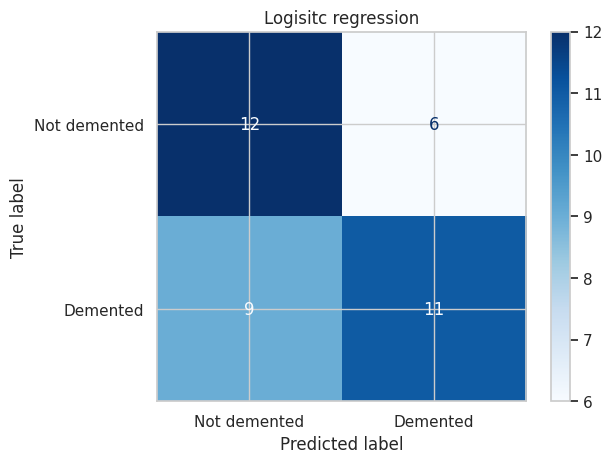

In [22]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
log_pred = log_model.predict(X_test)
print(classification_report(y_test, log_pred, target_names=["Not demented", "Demented"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, log_pred, display_labels=["Not demented", "Demented"], cmap="Blues")

plt.title("Logisitc regression")
plt.show()



- 12 non-demented people correctly predicted as not demented.
- 6 non-demented peolple wrongly flagged as demented.
- 9 people with dementia were missed, predcited as non-demented.
- 11 people with dementia correctly identified.
- 23/38 correct = 61%

              precision    recall  f1-score   support

Not demented       0.63      0.67      0.65        18
    Demented       0.68      0.65      0.67        20

    accuracy                           0.66        38
   macro avg       0.66      0.66      0.66        38
weighted avg       0.66      0.66      0.66        38



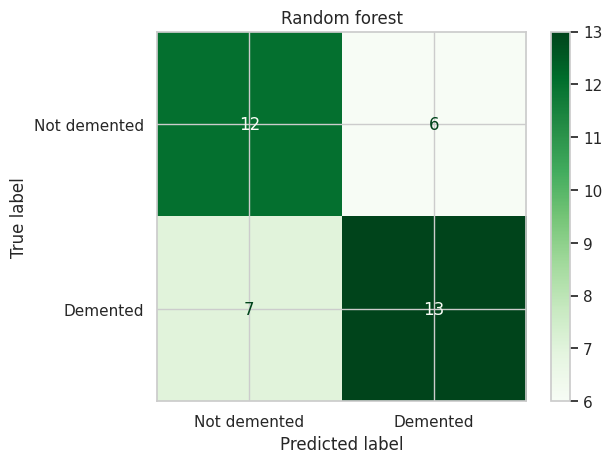

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_pred, target_names=["Not demented", "Demented"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=["Not demented", "Demented"], cmap="Greens")
plt.title("Random forest")
plt.show()


- 12 non-demented correctly identified.
- 6 wrong classifications.
- 7 people with dementia missed
- 13 people with dementia caught.
- 25/38 accuracy = 66%

In [24]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("Logistic regression", log_model),("Random forest", rf_model)]:
    scores = cross_validate(model, X, y, cv=cv, scoring=["accuracy", "recall", "roc_auc"])
    print(name)
    print(" Accuracy:", round(scores["test_accuracy"].mean(), 2))
    print( "Recall: ", round(scores["test_recall"].mean(), 2))
    print(" ROC AUC: ", round(scores["test_roc_auc"].mean(), 2)
)

Logistic regression
 Accuracy: 0.75
Recall:  0.65
 ROC AUC:  0.84
Random forest
 Accuracy: 0.79
Recall:  0.72
 ROC AUC:  0.82


- Random forest caught more people with dementia (72% vs 65%) and more accurate overall.

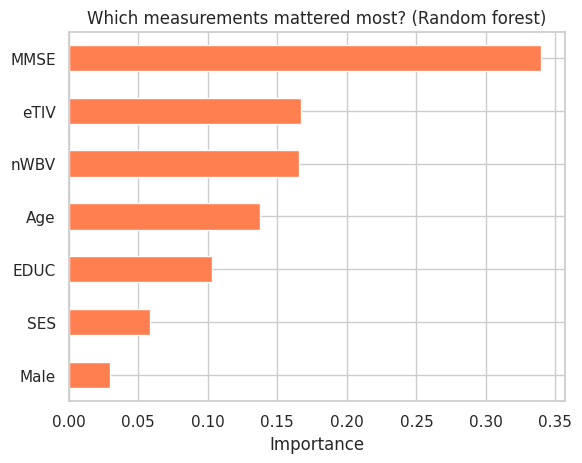

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="coral")
plt.title("Which measurements mattered most? (Random forest)")
plt.xlabel("Importance")
plt.show()


- MMSE most important feature for random forest (0.34) and has strongest correlation with dementia.
- Brain volume (nWBV) and skull size (eTIV) next, followed by age and education.
- eTIV and age ranked high despite having no direct correlation.
- Random forest may use eTIV andage in combination with other factors, may also reflect a known bias.